# Spark Background

What is Spark?
---
Spark is a data processing framework and parallel execution engine.

Why is Spark a popular framework?
---
Spark is popular for being fast, general purpose oriented, having native support of Python/Java/Scala/R, and enabling a high level of abstraction.

What is Spark SQL and why does it exist?
---
Spark SQL exists so people are already used to SQL can quickly adapt to a similar language while the RDD jobs are handled under the hood for them.

What is a Spark DataFrame, and why is it useful?
---
A Spark DataFrame is similar to a Pandas DataFrame built on a RDD and is optimized for distributed tabular computing.

# Setup / Data Collection

Link to Kaggle Data: https://www.kaggle.com/datasets/adilshamim8/student-depression-dataset/data

In [2]:
!pip install pyspark
!pip install kagglehub

In [3]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Test Dataset") \
    .enableHiveSupport() \
    .getOrCreate()

print(spark.sparkContext.appName)

Test Dataset


In [4]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("adilshamim8/student-depression-dataset")

print("Path to dataset files:", path)

Path to dataset files: /kaggle/input/student-depression-dataset


In [5]:
df = spark.read.csv("/kaggle/input/student-depression-dataset", header=True, inferSchema=True)
df.show()

+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+----------+-------------------------------------+----------------+----------------+--------------------------------+----------+
| id|Gender| Age|         City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|     Sleep Duration|Dietary Habits|    Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+----------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|  2|  Male|33.0|Visakhapatnam|   Student|              5.0|          0.0|8.97|               2.0|             0.0|        '5-6 hours'|       Healthy|   B.Pharm|     

# Data Cleaning

## Check for missing numbers

In [6]:
from pyspark.sql.functions import isnan, when, count, col

df.select([count(when(isnan(c), c)).alias(c) for c in df.columns]).show()

+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
| id|Gender|Age|City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|Sleep Duration|Dietary Habits|Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|  0|     0|  0|   0|         0|                0|            0|   0|                 0|               0|             0|             0|     0|                                    0|               0|               0|         

## Check for missing text

In [7]:
from pyspark.sql.functions import col, length

text_cols = ['Gender', 'City', 'Profession', 'Sleep Duration', 'Dietary Habits', 'Degree', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness']

for col_name in text_cols:
  df.filter(col(col_name).isNull() | (length(col(col_name)) == 0)).show()

+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
| id|Gender|Age|City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|Sleep Duration|Dietary Habits|Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+---------

## Check for duplicates

In [8]:
df.groupBy(df.columns).agg(count('*').alias('duplicates')).filter(col('duplicates') > 1).show()

+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+----------+
| id|Gender|Age|City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|Sleep Duration|Dietary Habits|Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|duplicates|
+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+----------+
+---+------+---+----+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+------+-------------------------------------+----------

## Check for outliers (in numeric columns)

In [9]:
# Using Z-Score

from pyspark.sql.functions import col, mean, stddev, abs, max, min

def check_outliers(df, column):
  stats = df.agg(mean(column).alias('mean'), stddev(column).alias('stddev'),
                 max(column).alias('max'), min(column).alias('min')).collect()[0]

  df_zscored = df.withColumn('z_score', (col(column)-stats.mean)/stats.stddev)
  outliers_df = df_zscored.filter(abs(col('z_score')) > 3)

  print(f'Max: {stats.max}\nMin: {stats.min}\nMean: {stats.mean}')
  print(f'Standard Deviation: {stats.stddev}')
  print('\nDataFrame with Z-scores added:')
  df_zscored.show(5)

  print(f'\nThere are {outliers_df.count()} outliers:')
  outliers_df.show()

In [10]:
num_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress', 'Depression']

for col_name in num_cols:
  print(f'\n{col_name}:')
  check_outliers(df, col_name)


Age:
Max: 59.0
Min: 18.0
Mean: 25.82230027597577
Standard Deviation: 4.905687448924319

DataFrame with Z-scores added:
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+-------+-------------------------------------+----------------+----------------+--------------------------------+----------+--------------------+
| id|Gender| Age|         City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|     Sleep Duration|Dietary Habits| Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|             z_score|
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+-------+-------------------------------------+----------------+----------------+--------------------------------+----------+--------------

The financial stress column has a `?` because there is a string in the column that should only contain values from 0 to 5.

In [11]:
from pyspark.sql.functions import col, when

errant_rows = df.filter(~col("Financial Stress").cast("double").isNotNull())
print("\nErrant Rows (before casting):")
errant_rows.show()

# Cast 'Financial Stress' to double
df = df.withColumn('Financial Stress', col('Financial Stress').cast('double'))

print(f'\nFinancial Stress (after casting and null handling):')
check_outliers(df, 'Financial Stress')



Errant Rows (before casting):
+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|   id|Gender| Age|     City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|     Sleep Duration|Dietary Habits|Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|
+-----+------+----+---------+----------+-----------------+-------------+----+------------------+----------------+-------------------+--------------+------+-------------------------------------+----------------+----------------+--------------------------------+----------+
|22377|Female|32.0| Varanasi|   Student|              3.0|          0.0|5.64|               1.0|             0.0|        '5-6 hours'|       Healthy|   BC

## Check for outliers (misspellings in text columns)

In [12]:
from pyspark.sql.functions import col, countDistinct, count

# text_cols was defined previously when checking for missing text
for col_name in text_cols:
  df.groupBy(col_name).agg(count('*').alias('count')).orderBy(col('count').desc()).show()

+------+-----+
|Gender|count|
+------+-----+
|  Male|15547|
|Female|12354|
+------+-----+

+-------------+-----+
|         City|count|
+-------------+-----+
|       Kalyan| 1570|
|     Srinagar| 1372|
|    Hyderabad| 1340|
|  Vasai-Virar| 1290|
|      Lucknow| 1155|
|        Thane| 1139|
|     Ludhiana| 1111|
|         Agra| 1094|
|        Surat| 1078|
|      Kolkata| 1066|
|       Jaipur| 1036|
|        Patna| 1007|
|Visakhapatnam|  969|
|         Pune|  968|
|    Ahmedabad|  951|
|       Bhopal|  934|
|      Chennai|  885|
|       Meerut|  825|
|       Rajkot|  816|
|        Delhi|  768|
+-------------+-----+
only showing top 20 rows

+--------------------+-----+
|          Profession|count|
+--------------------+-----+
|             Student|27870|
|           Architect|    8|
|             Teacher|    6|
|  'Digital Marketer'|    3|
|                Chef|    2|
|    'Content Writer'|    2|
|          Pharmacist|    2|
|              Doctor|    2|
|'Educational Cons...|    1|
|      

Outside of the few `?` values in Financial Stress there are no duplicates, missing or null values, type inconsistencies, or misspellings/mistypings.

There are 9 outliers in the CGPA column where students have CGPA's of 0 (they could be failing all their courses). And when using the z-score method, it flags the older students (41+) as outliers as well as student with values in Work Pressure or Job Satisfaction because the average student value is so low (I'm guessing it is because most students aren't working).

All in all, very little modifications made. The outliers have plausible explanations and so I don't want to remove them.

# Data Exploration

## Schema of Dataset

In [13]:
df.printSchema()

root
 |-- id: integer (nullable = true)
 |-- Gender: string (nullable = true)
 |-- Age: double (nullable = true)
 |-- City: string (nullable = true)
 |-- Profession: string (nullable = true)
 |-- Academic Pressure: double (nullable = true)
 |-- Work Pressure: double (nullable = true)
 |-- CGPA: double (nullable = true)
 |-- Study Satisfaction: double (nullable = true)
 |-- Job Satisfaction: double (nullable = true)
 |-- Sleep Duration: string (nullable = true)
 |-- Dietary Habits: string (nullable = true)
 |-- Degree: string (nullable = true)
 |-- Have you ever had suicidal thoughts ?: string (nullable = true)
 |-- Work/Study Hours: double (nullable = true)
 |-- Financial Stress: double (nullable = true)
 |-- Family History of Mental Illness: string (nullable = true)
 |-- Depression: integer (nullable = true)



## Shape of Dataset

In [14]:
print((df.count(), len(df.columns)))

(27901, 18)


## Summary Statistics

In [15]:
df.describe().show()

+-------+-----------------+------+-----------------+-------------+----------------+------------------+--------------------+------------------+------------------+--------------------+--------------+--------------+----------+-------------------------------------+------------------+------------------+--------------------------------+------------------+
|summary|               id|Gender|              Age|         City|      Profession| Academic Pressure|       Work Pressure|              CGPA|Study Satisfaction|    Job Satisfaction|Sleep Duration|Dietary Habits|    Degree|Have you ever had suicidal thoughts ?|  Work/Study Hours|  Financial Stress|Family History of Mental Illness|        Depression|
+-------+-----------------+------+-----------------+-------------+----------------+------------------+--------------------+------------------+------------------+--------------------+--------------+--------------+----------+-------------------------------------+------------------+----------------

## Column Meanings

id - Unique Identifier\
Gender - Gender\
Age - Age in years\
City - Current resident city of person responding\
Profession - Field of Work/Study\
Academic Pressure - 0 to 5 with 0 as low and 5 as high (Self-estimate)\
Work Pressure - 0 to 5 with 0 as low and 5 as high (Self-estimate)\
CGPA - Cumulative Grade Point Average\
Study Satisfaction - 0 to 5 with 0 as low and 5 as high (Self-estimate)\
Job Satisfaction - 0 to 5 with 0 as low and 5 as high (Self-estimate)\
Sleep Duration - Average number of hours the student sleeps per day\
Dietary Habits - (Healthy, Moderate, Unhealthy, Others) Estimate of Diet healthiness \
Degree - Academic Program the student is currently pursuing
Have you ever had suicidal thoughs ? - (Yes/No) Self explanatory \
Work/Study Hours - Average number of house the students work/study per day\
Financial Stress - 0 to 5 with 0 as low and 5 as high (Self-estimate)\
Family History of Mental Illness - (Yes/No) Self explanatory\
Depression - Label, 0 for no, 1 for yes

### Distribution of Columns

In [16]:
import matplotlib.pyplot as plt

def create_histograms(df, column, bins):
  # Create a histogram with 30 bins
  hist = df.select(column).rdd.flatMap(lambda x: x).histogram(bins)

  # Calculate bin centers for plotting
  width = hist[0][1] - hist[0][0]
  centers = [hist[0][0] + (i + 0.5)*width for i in range(len(hist[1]))]

  # Plot
  plt.bar(centers, hist[1], width=width, edgecolor='black')
  plt.xlabel(column)
  plt.ylabel('Frequency')
  plt.title(f'Histogram Plot')
  plt.show()

def create_bargraph(df, column):
  # Create a bar graph
  df.groupBy(column).count().orderBy('count', ascending=False).show()
  df.groupBy(column).count().orderBy('count', ascending=False).toPandas().plot.bar(x=column, y='count')
  plt.xlabel(column)
  plt.ylabel('Frequency')
  plt.title(f'Bar Graph')
  plt.show()

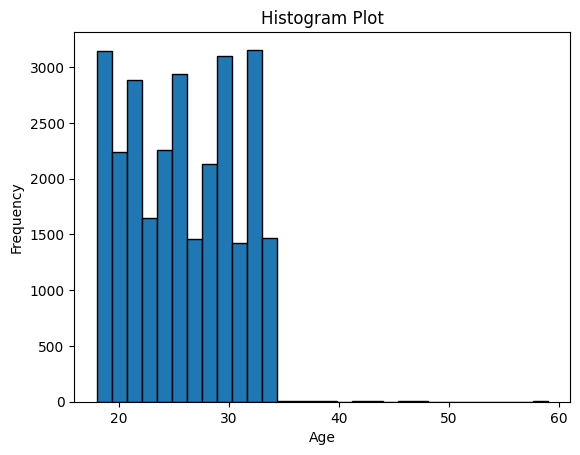

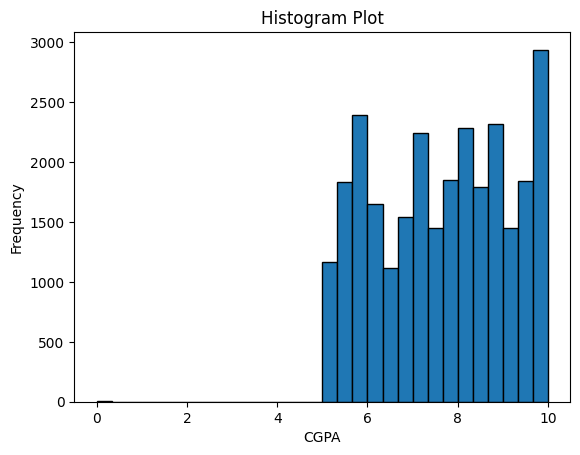

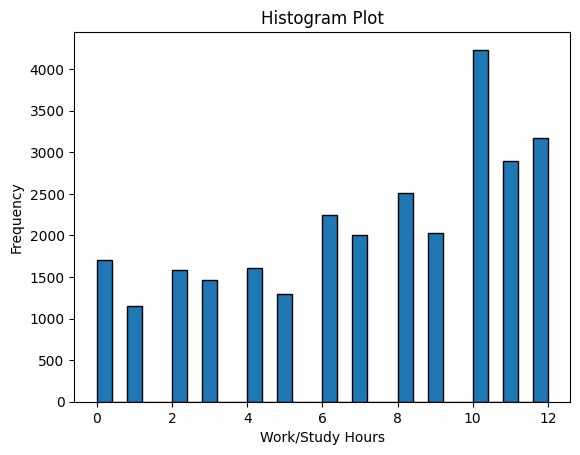

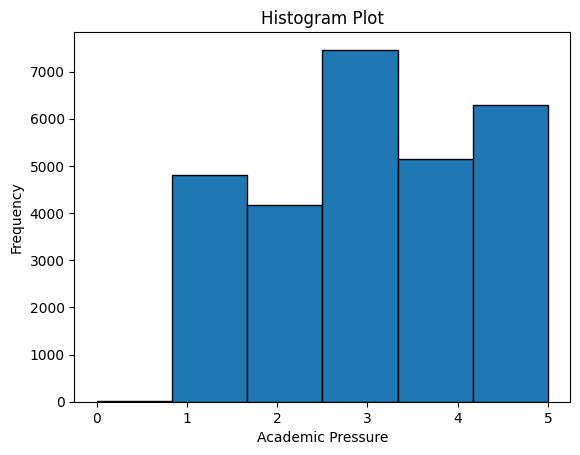

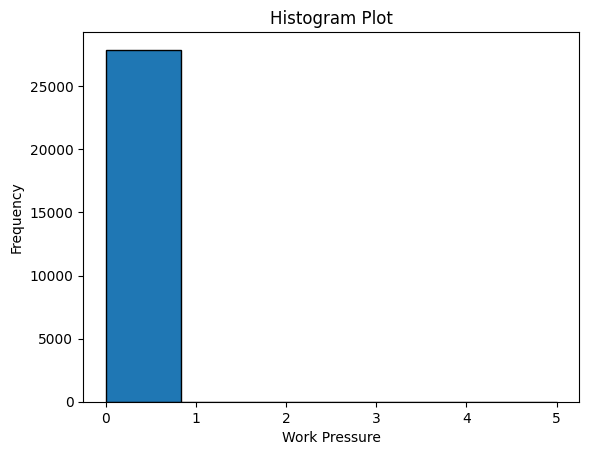

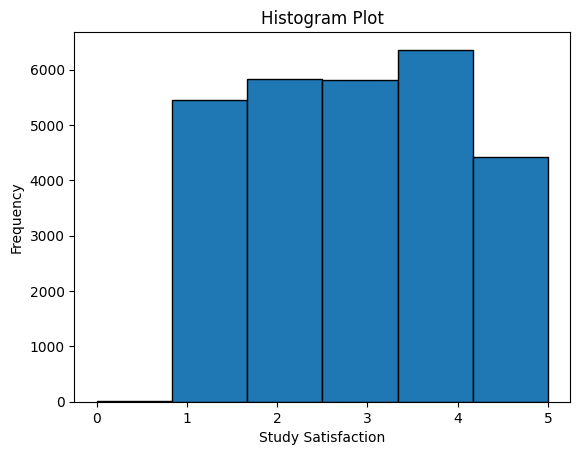

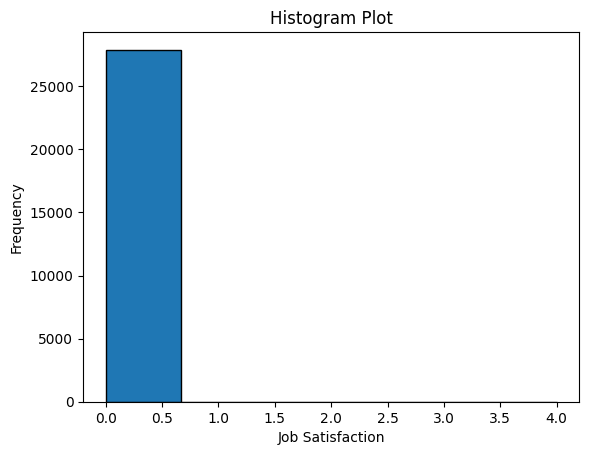

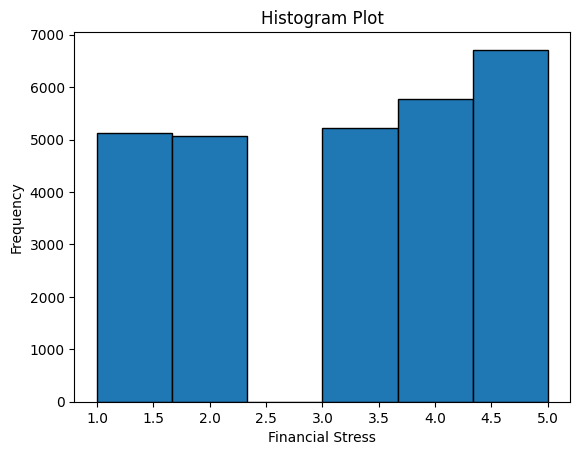

+------+-----+
|Gender|count|
+------+-----+
|  Male|15547|
|Female|12354|
+------+-----+



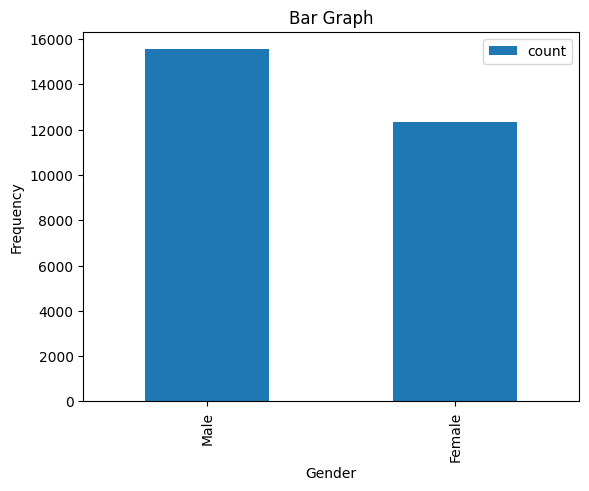

+-------------------------------------+-----+
|Have you ever had suicidal thoughts ?|count|
+-------------------------------------+-----+
|                                  Yes|17656|
|                                   No|10245|
+-------------------------------------+-----+



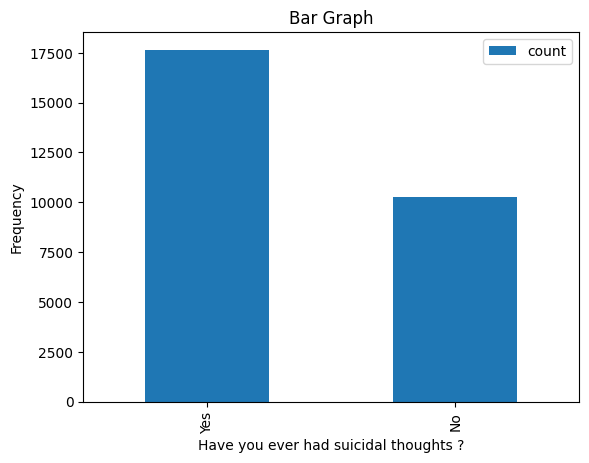

+--------------------------------+-----+
|Family History of Mental Illness|count|
+--------------------------------+-----+
|                              No|14398|
|                             Yes|13503|
+--------------------------------+-----+



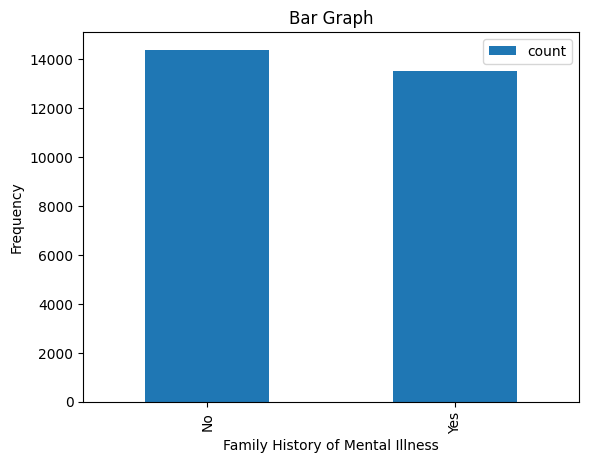

+----------+-----+
|Depression|count|
+----------+-----+
|         1|16336|
|         0|11565|
+----------+-----+



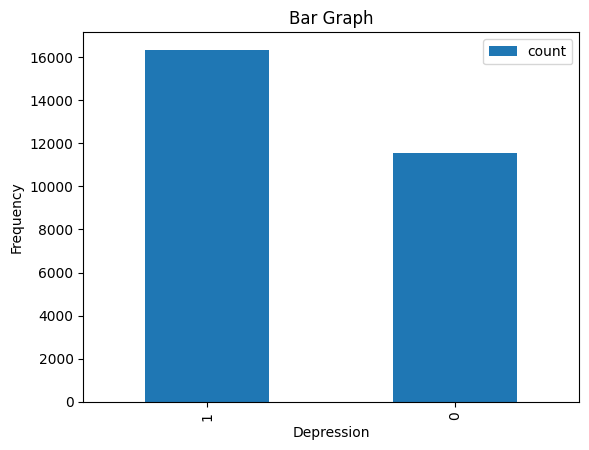

+-------------+-----+
|         City|count|
+-------------+-----+
|       Kalyan| 1570|
|     Srinagar| 1372|
|    Hyderabad| 1340|
|  Vasai-Virar| 1290|
|      Lucknow| 1155|
|        Thane| 1139|
|     Ludhiana| 1111|
|         Agra| 1094|
|        Surat| 1078|
|      Kolkata| 1066|
|       Jaipur| 1036|
|        Patna| 1007|
|Visakhapatnam|  969|
|         Pune|  968|
|    Ahmedabad|  951|
|       Bhopal|  934|
|      Chennai|  885|
|       Meerut|  825|
|       Rajkot|  816|
|        Delhi|  768|
+-------------+-----+
only showing top 20 rows



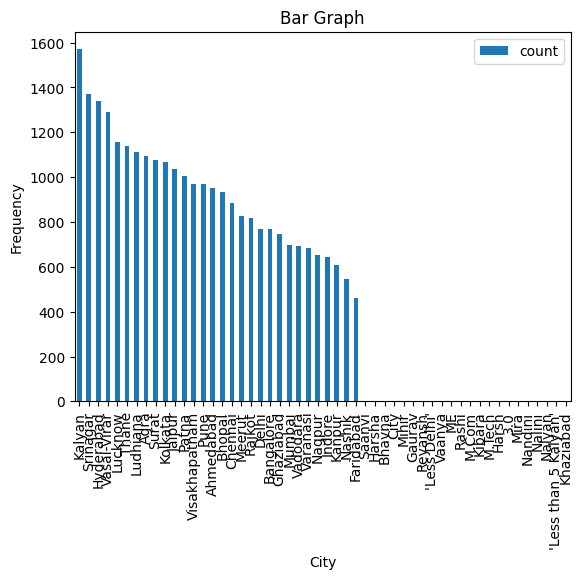

+--------------------+-----+
|          Profession|count|
+--------------------+-----+
|             Student|27870|
|           Architect|    8|
|             Teacher|    6|
|  'Digital Marketer'|    3|
|                Chef|    2|
|    'Content Writer'|    2|
|          Pharmacist|    2|
|              Doctor|    2|
|'Educational Cons...|    1|
|              Lawyer|    1|
|    'UX/UI Designer'|    1|
|        Entrepreneur|    1|
|             Manager|    1|
|    'Civil Engineer'|    1|
+--------------------+-----+



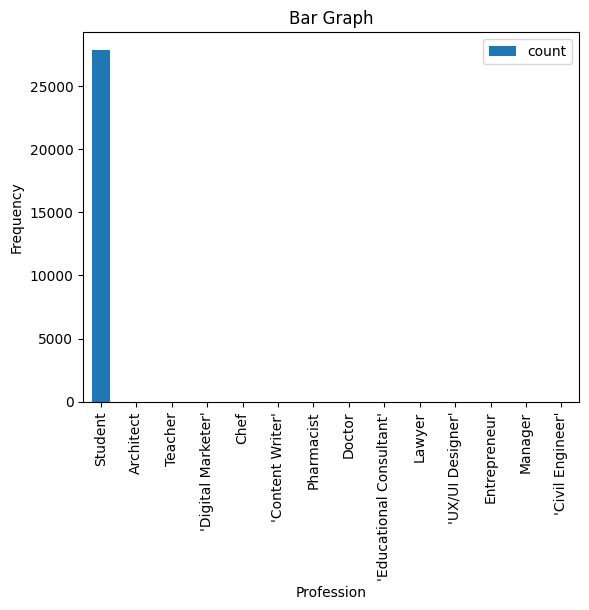

+--------------+-----+
|Dietary Habits|count|
+--------------+-----+
|     Unhealthy|10317|
|      Moderate| 9921|
|       Healthy| 7651|
|        Others|   12|
+--------------+-----+



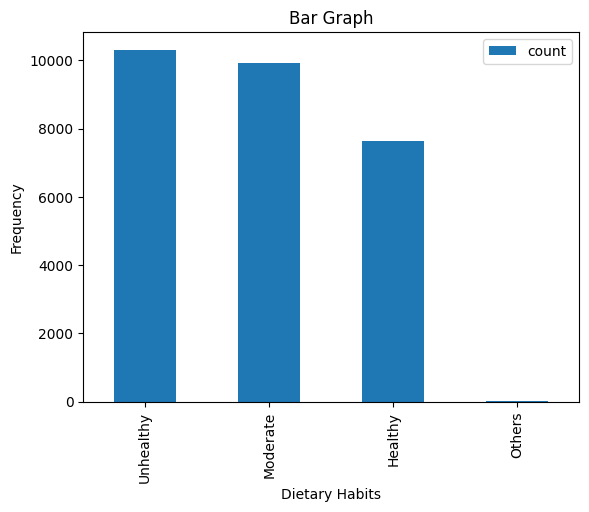

+----------+-----+
|    Degree|count|
+----------+-----+
|'Class 12'| 6080|
|      B.Ed| 1867|
|     B.Com| 1506|
|    B.Arch| 1478|
|       BCA| 1433|
|       MSc| 1190|
|    B.Tech| 1152|
|       MCA| 1044|
|    M.Tech| 1022|
|       BHM|  925|
|       BSc|  888|
|      M.Ed|  821|
|   B.Pharm|  810|
|     M.Com|  734|
|      MBBS|  696|
|       BBA|  696|
|       LLB|  671|
|        BE|  613|
|        BA|  600|
|   M.Pharm|  582|
+----------+-----+
only showing top 20 rows



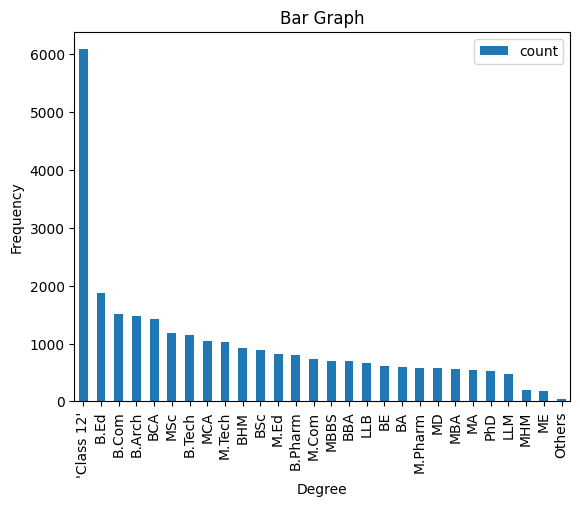

+-------------------+-----+
|     Sleep Duration|count|
+-------------------+-----+
|'Less than 5 hours'| 8310|
|        '7-8 hours'| 7346|
|        '5-6 hours'| 6183|
|'More than 8 hours'| 6044|
|             Others|   18|
+-------------------+-----+



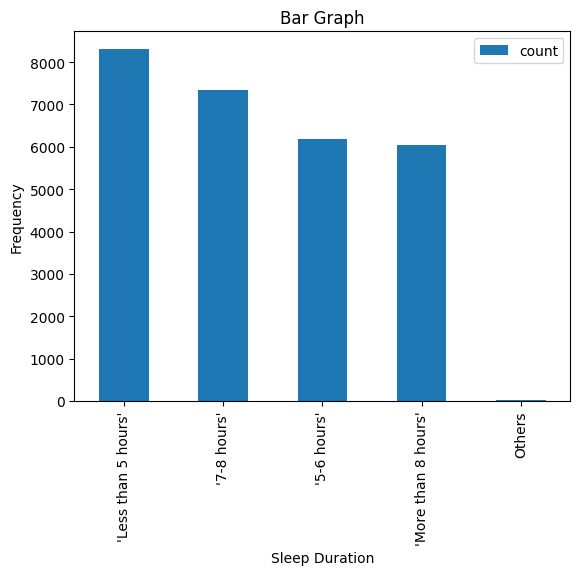

In [17]:
# Select columns of interest
cols_cont = ['Age',  'CGPA', 'Work/Study Hours']

# 0 to 5 columns
cols_z_f = ['Academic Pressure', 'Work Pressure', 'Study Satisfaction', 'Job Satisfaction', 'Financial Stress']

# 2 columns
cols_binary = ['Gender', 'Have you ever had suicidal thoughts ?', 'Family History of Mental Illness', 'Depression']

# Categorical column
cols_cat = [ 'City', 'Profession', 'Dietary Habits', 'Degree',  'Sleep Duration']

for col_name in cols_cont:
  create_histograms(df, col_name, 30)

for col_name in cols_z_f:
  create_histograms(df, col_name, 6)

for col_name in cols_binary:
  create_bargraph(df, col_name)

for col_name in cols_cat:
  create_bargraph(df, col_name)

# Machine Learning

In [18]:
# import pyspark.ml libraries for binary classification
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml.classification import LogisticRegression
from pyspark.ml.evaluation import BinaryClassificationEvaluator

indexer = StringIndexer(inputCol="Depression", outputCol="label")
indexed_df = indexer.fit(df).transform(df)
input_cols = ['Age', 'Academic Pressure', 'Work Pressure', 'CGPA', 'Study Satisfaction', 'Job Satisfaction', 'Work/Study Hours', 'Financial Stress']
assembler = VectorAssembler(inputCols=input_cols, outputCol="features", handleInvalid="skip")
data = assembler.transform(indexed_df)

# Split the data into 80/20 train test split
training, test = data.randomSplit([0.8, 0.2], seed=42)
training.show(n=2)

# Create a logistic regression model
model = LogisticRegression(maxIter=5000, featuresCol="features", labelCol="label")
model = model.fit(training)

# Make predictions on the test data
predictions = model.transform(test)

print(f'Accuracy: {model.summary.accuracy}')
print(f'Precision: {model.summary.weightedPrecision}')
print(f'Recall: {model.summary.weightedRecall}')
print(f'F1 Score: {model.summary.weightedFMeasure()}')

+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+-------+-------------------------------------+----------------+----------------+--------------------------------+----------+-----+--------------------+
| id|Gender| Age|         City|Profession|Academic Pressure|Work Pressure|CGPA|Study Satisfaction|Job Satisfaction|Sleep Duration|Dietary Habits| Degree|Have you ever had suicidal thoughts ?|Work/Study Hours|Financial Stress|Family History of Mental Illness|Depression|label|            features|
+---+------+----+-------------+----------+-----------------+-------------+----+------------------+----------------+--------------+--------------+-------+-------------------------------------+----------------+----------------+--------------------------------+----------+-----+--------------------+
|  2|  Male|33.0|Visakhapatnam|   Student|              5.0|          0.0|8.97|               2.0|           

What ML task and algorithm was chosen?
---
The task was Binary Classification and the algorithm was logistic regression.

Results
---
The results show a prediction accuracy of 78.7% using the feature vector of Age, Academic Pressure, Work, Pressure, CGPA, Study Satisfaction, Job Satisfaction, Work/Study Hours, and Financial Stress. This could be made better if the text columns where also encoded into values as this could provide more data that could help the prediction.

# [Bugged] Graphs in Spark

In [19]:
!pip install graphframes

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.7/154.7 kB 4.0 MB/s eta 0:00:00


In [20]:
!pwd

/content
